# Mathematical Morphology Training Notebook  
## Hit-or-Miss Transform, Boundary Extraction, Hole Filling, and Connected Components

This notebook is designed for teaching students the core binary morphological operations used in image processing.

### Learning goals
By the end of this notebook, students should be able to:

1. Explain the purpose of each operation.
2. Write and run sample code for each technique.
3. Interpret the visual output.
4. Modify the code to solve short exercises.
5. Connect the implementation to the underlying mathematical equations.

---

## Topics covered
- Hit-or-Miss Transform
- Boundary Extraction
- Hole Filling
- Extraction of Connected Components

---

## Recommended background
Students should already know:
- Binary image representation
- Foreground and background concepts
- Basic set notation
- Erosion and dilation
- Python basics

## Morphology refresher

Let a binary image be represented by a set $$ A \subseteq \mathbb{Z}^2 $$, where each foreground pixel belongs to the set.

Let $$ B $$ be a structuring element.

### Fundamental operations

**Erosion**
$$
A \ominus B = \{ z \mid B_z \subseteq A \}
$$

**Dilation**
$$
A \oplus B = \{ z \mid (\hat{B})_z \cap A \neq \emptyset \}
$$

where $$ \hat{B} $$ is the reflection of $$ B $$.

These basic operators are used to build more advanced morphology methods.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from matplotlib import colors

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

def show(img, title="", ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

def show_pair(a, b, title1="Input", title2="Result"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    show(a, title1, axes[0])
    show(b, title2, axes[1])
    plt.tight_layout()

def show_triplet(a, b, c, t1="A", t2="B", t3="C"):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    show(a, t1, axes[0])
    show(b, t2, axes[1])
    show(c, t3, axes[2])
    plt.tight_layout()

## Synthetic binary test images

To make the notebook self-contained, we will generate simple binary images directly in code.

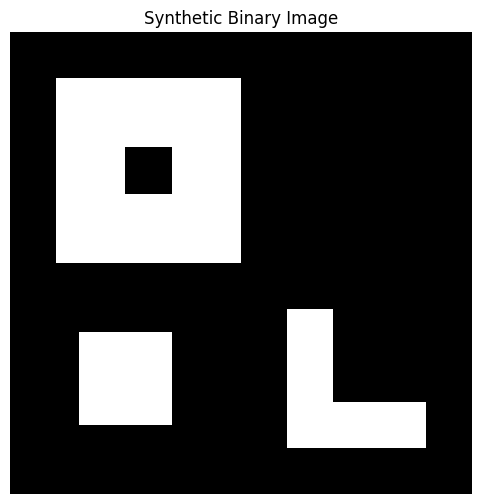

In [27]:
# Create a synthetic image with blocks, a hole, and separate objects
img = np.zeros((20, 20), dtype=np.uint8)

# Large square
img[2:10, 2:10] = 1

# Hole inside the large square
img[5:7, 5:7] = 0

# Small object
img[13:17, 3:7] = 1

# L-shape object
img[12:18, 12:14] = 1
img[16:18, 12:18] = 1

show(img, "Synthetic Binary Image")
plt.show()

# 1. Hit-or-Miss Transform

The hit-or-miss transform detects a very specific binary pattern in an image.

It is useful when we want to find:
- end points,
- corners,
- isolated pixels,
- exact local configurations.

---

## Definition

Suppose:
- $$ A $$ is the binary image,
- $$ B_1 $$ is the structuring element for foreground,
- $$ B_2 $$ is the structuring element for background.

Then the hit-or-miss transform is:

$$
A \circledast (B_1, B_2) = (A \ominus B_1) \cap (A^c \ominus B_2)
$$

This means:
- the foreground pattern must match $$ B_1 $$,
- the background pattern must match $$ B_2 $$.

So the operation is an exact pattern detector.

## Intuition

A location is marked as a match only if:
- all required foreground pixels are present, and
- all required background pixels are absent from the object.

This makes hit-or-miss stricter than standard erosion.

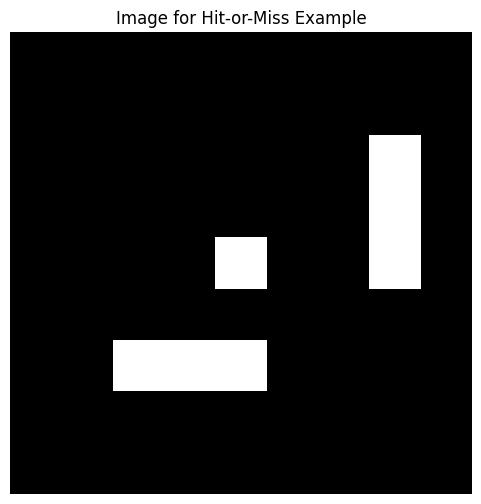

In [28]:
# Example image for hit-or-miss: detect isolated center pattern
hm_img = np.zeros((9, 9), dtype=np.uint8)
hm_img[4, 4] = 1
hm_img[2:5, 7] = 1
hm_img[6, 2:5] = 1

show(hm_img, "Image for Hit-or-Miss Example")
plt.show()

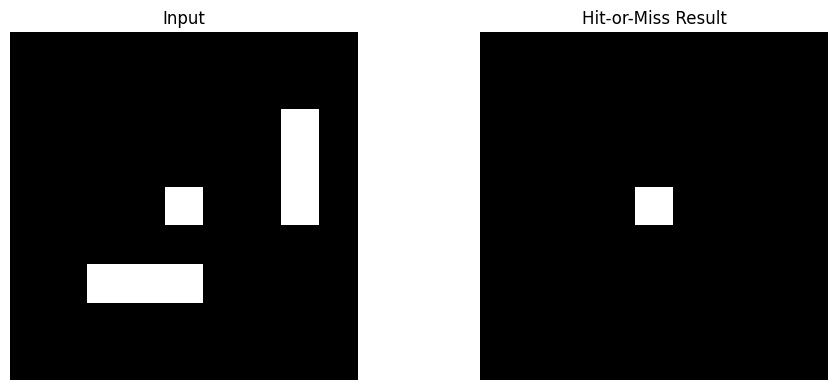

In [29]:
# Pattern: isolated single foreground pixel surrounded by background
B1 = np.array([[0,0,0],
               [0,1,0],
               [0,0,0]], dtype=bool)

# For the background mask, all 8 neighbors should be background
B2 = np.array([[1,1,1],
               [1,0,1],
               [1,1,1]], dtype=bool)

foreground_match = ndimage.binary_erosion(hm_img, structure=B1)
background_match = ndimage.binary_erosion(1 - hm_img, structure=B2)
hitmiss = foreground_match & background_match

show_pair(hm_img, hitmiss.astype(np.uint8), "Input", "Hit-or-Miss Result")
plt.show()

## Discussion

The result highlights only pixels that exactly satisfy the required foreground and background arrangement.

In this example, the transform detects the isolated single pixel, but not pixels that belong to a line.

## Student exercise: hit-or-miss for end-point detection

Modify the structuring elements so that the operation detects an end point of a line.

Hint:
- The center pixel should be foreground.
- One neighbor should also be foreground.
- Other surrounding positions should be background.

Try several orientations.

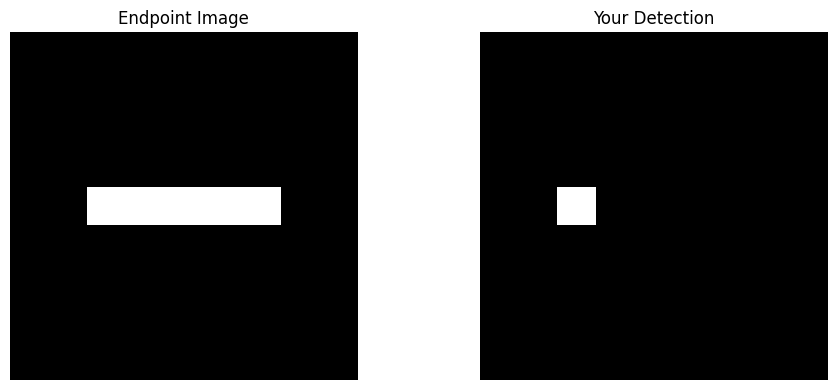

In [30]:
# Student task cell: define new B1 and B2 for endpoint detection

# Example image
endpoint_img = np.zeros((9, 9), dtype=np.uint8)
endpoint_img[4, 2:7] = 1

# TODO: replace these with your own endpoint pattern
B1_student = np.array([[0,0,0],
                       [0,1,1],
                       [0,0,0]], dtype=bool)

B2_student = np.array([[1,1,1],
                       [1,0,0],
                       [1,1,1]], dtype=bool)

fg = ndimage.binary_erosion(endpoint_img, structure=B1_student)
bg = ndimage.binary_erosion(1 - endpoint_img, structure=B2_student)
result_student = fg & bg

show_pair(endpoint_img, result_student.astype(np.uint8), "Endpoint Image", "Your Detection")
plt.show()

# 2. Boundary Extraction

Boundary extraction finds the border pixels of an object.

---

## Equation

If $$ A $$ is the binary image and $$ B $$ is a structuring element, the boundary of $$ A $$ is:

$$
\beta(A) = A - (A \ominus B)
$$

### Interpretation
- $$ A \ominus B $$ removes one layer of pixels from the object.
- Subtracting the eroded image from the original leaves the boundary.

This is a simple and very common way to isolate the outer contour of binary objects.

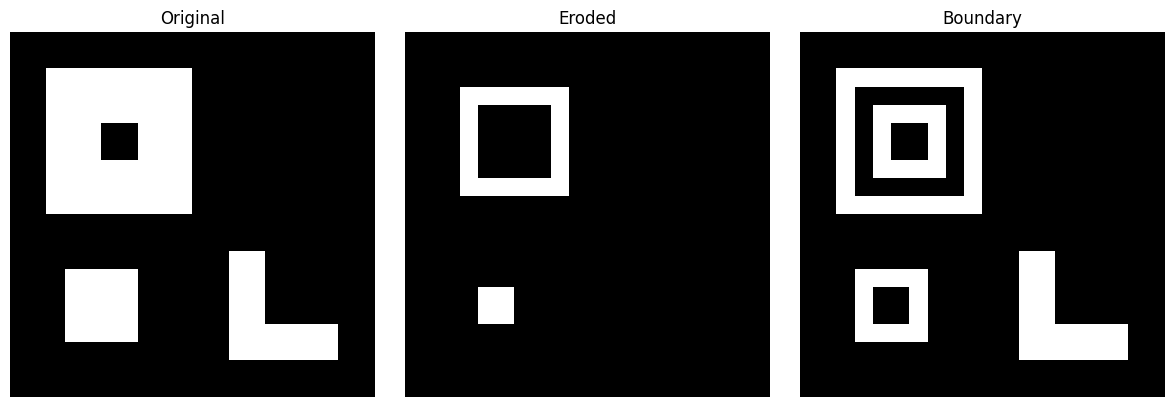

In [31]:
se = np.ones((3, 3), dtype=bool)
eroded = ndimage.binary_erosion(img, structure=se)
boundary = img & (~eroded)

show_triplet(img, eroded.astype(np.uint8), boundary.astype(np.uint8),
             "Original", "Eroded", "Boundary")
plt.show()

## Observation

The erosion shrinks the object.  
The pixels removed during this shrinking process form the boundary.

## Student exercise: compare boundary thickness

Try different structuring elements:
- 3x3 square
- cross-shaped element
- 5x5 square

Question:
How does the boundary change when the structuring element becomes larger?

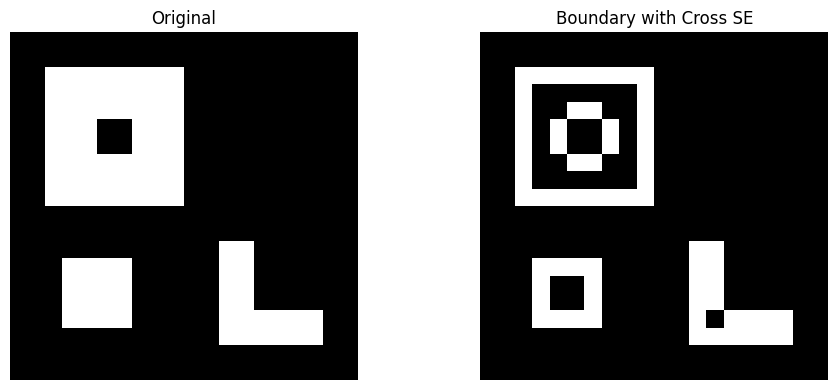

In [32]:
# Student task cell: experiment with different structuring elements
cross = np.array([[0,1,0],
                  [1,1,1],
                  [0,1,0]], dtype=bool)

eroded_cross = ndimage.binary_erosion(img, structure=cross)
boundary_cross = img & (~eroded_cross)

show_pair(img, boundary_cross.astype(np.uint8), "Original", "Boundary with Cross SE")
plt.show()

# 3. Hole Filling

Hole filling is used to fill interior background regions that are fully surrounded by foreground.

A **hole** is a background region that is not connected to the image border.

---

## Morphological formulation

Let:
- $$ A $$ be the foreground object set,
- $$ A^c $$ be the background,
- $$ X_0 $$ be a seed point inside a hole.

Then iterative geodesic dilation can be used:

$$
X_k = (X_{k-1} \oplus B) \cap A^c
$$

Repeat until stability:

$$
X_k = X_{k-1}
$$

Then the filled image is:

$$
A_{\text{filled}} = A \cup X_k
$$

This means we grow a region from a seed inside the hole, but constrain the growth so it remains inside the background hole.

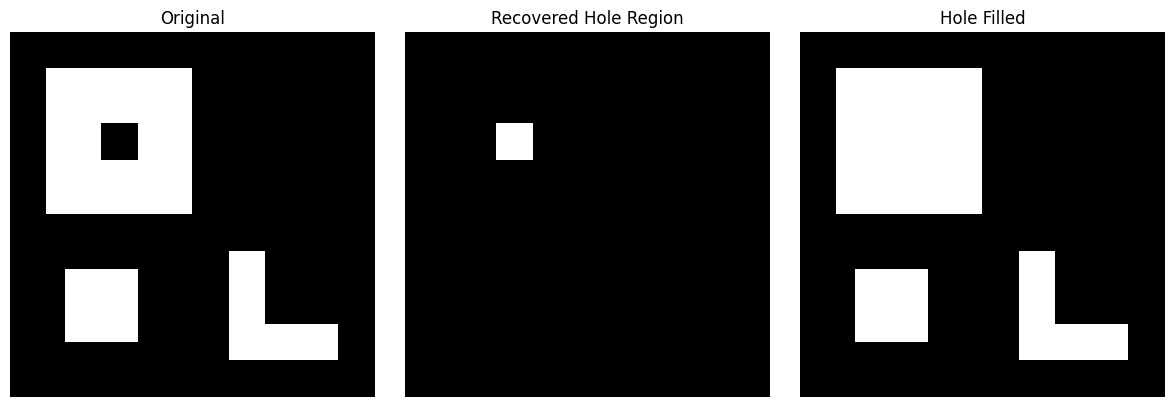

In [33]:
# Use a seed inside the hole of the large square
seed = np.zeros_like(img, dtype=bool)
seed[5, 5] = True  # seed inside hole

background = ~img.astype(bool)
structure = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]], dtype=bool)

X_prev = seed.copy()

while True:
    X_next = ndimage.binary_dilation(X_prev, structure=structure) & background
    if np.array_equal(X_next, X_prev):
        break
    X_prev = X_next

filled_hole_region = X_prev
filled_img = img.astype(bool) | filled_hole_region

show_triplet(img, filled_hole_region.astype(np.uint8), filled_img.astype(np.uint8),
             "Original", "Recovered Hole Region", "Hole Filled")
plt.show()

## Alternative idea

A practical strategy for full hole filling is:
1. Mark the background connected to the border.
2. Any background not connected to the border is a hole.
3. Convert those holes to foreground.

This is often how hole filling is implemented in practice.

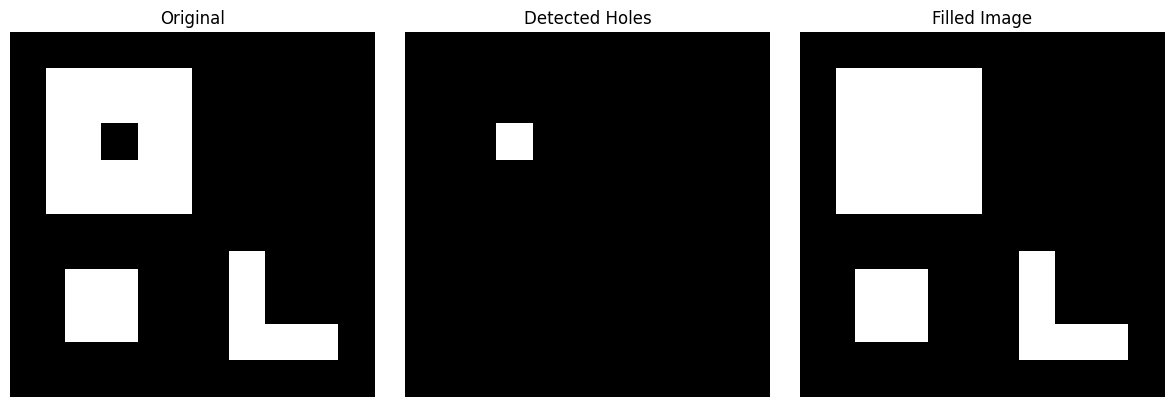

In [34]:
# Border-based hole filling
inv = 1 - img
seed_border = np.zeros_like(inv, dtype=bool)

seed_border[0, :] = inv[0, :]
seed_border[-1, :] = inv[-1, :]
seed_border[:, 0] = inv[:, 0]
seed_border[:, -1] = inv[:, -1]

outside = seed_border.copy()
while True:
    grown = ndimage.binary_dilation(outside, structure=structure) & inv.astype(bool)
    if np.array_equal(grown, outside):
        break
    outside = grown

holes = inv.astype(bool) & (~outside)
filled_by_border = img.astype(bool) | holes

show_triplet(img, holes.astype(np.uint8), filled_by_border.astype(np.uint8),
             "Original", "Detected Holes", "Filled Image")
plt.show()

## Student exercise: multiple holes

Create a new image with:
- two separate holes,
- one gap that touches the border.

Then test whether the algorithm fills only the true holes and not the border-connected background.

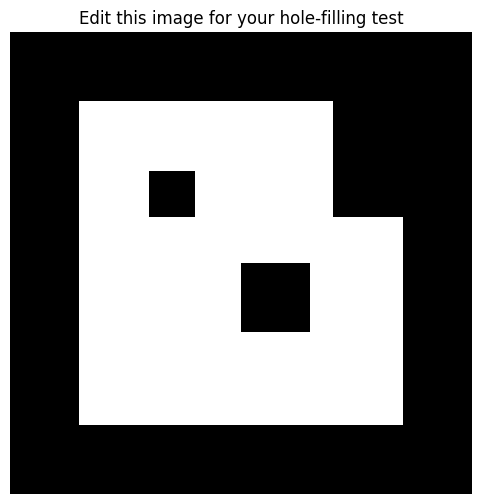

In [35]:
# Student task cell: build your own image here
student_holes = np.zeros((20, 20), dtype=np.uint8)
student_holes[3:17, 3:17] = 1
student_holes[6:8, 6:8] = 0
student_holes[10:13, 10:13] = 0
student_holes[3:8, 14:17] = 0  # border-connected gap because it touches outer object boundary

show(student_holes, "Edit this image for your hole-filling test")
plt.show()

# 4. Extraction of Connected Components

Connected component extraction isolates all pixels belonging to one connected object.

This is essential for:
- object counting,
- measuring area,
- segmentation post-processing,
- keeping only the largest object,
- removing small noise components.

---

## Morphological formulation from a seed

Let \( A \) be a binary image, and let \( X_0 \) be a seed inside one component.

Then:

$$
X_k = (X_{k-1} \oplus B) \cap A
$$

Repeat until stability:

$$
X_k = X_{k-1}
$$

The final set $$ X_k $$ is the connected component containing the seed.

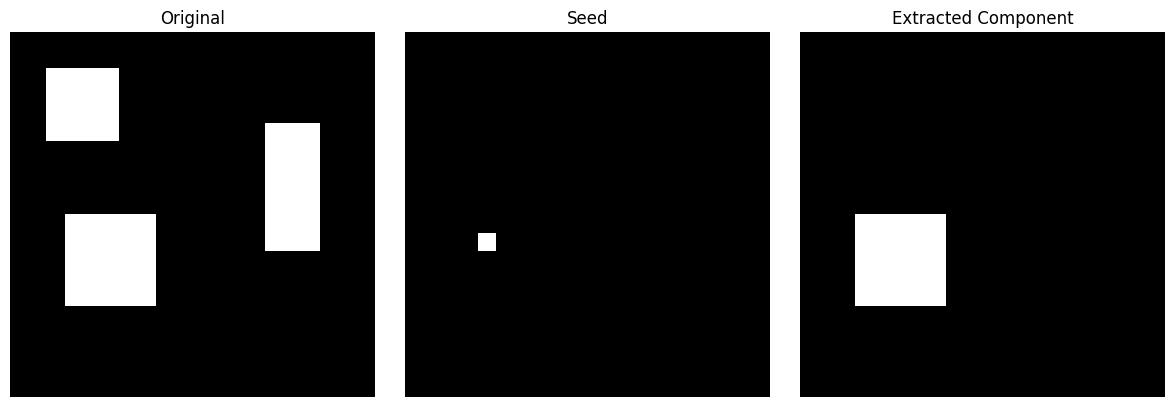

In [36]:
cc_img = np.zeros((20, 20), dtype=np.uint8)
cc_img[2:6, 2:6] = 1
cc_img[10:15, 3:8] = 1
cc_img[5:12, 14:17] = 1

seed_component = np.zeros_like(cc_img, dtype=bool)
seed_component[11, 4] = True  # inside second component

component = seed_component.copy()
while True:
    grown = ndimage.binary_dilation(component, structure=structure) & cc_img.astype(bool)
    if np.array_equal(grown, component):
        break
    component = grown

show_triplet(cc_img, seed_component.astype(np.uint8), component.astype(np.uint8),
             "Original", "Seed", "Extracted Component")
plt.show()

## Using automatic labeling

Instead of manually providing a seed, we can label all connected components automatically.

Number of connected components: 3
Labels present: [0 1 2 3]


/tmp/ipykernel_3388/1376084510.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("nipy_spectral", num_features + 1)


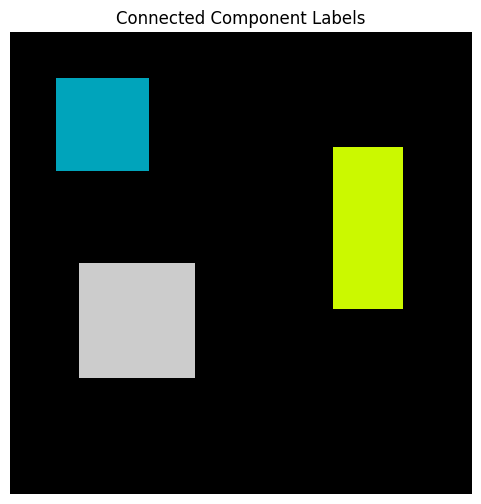

In [37]:
labeled, num_features = ndimage.label(cc_img)

print("Number of connected components:", num_features)
print("Labels present:", np.unique(labeled))

fig, ax = plt.subplots(figsize=(6, 6))
cmap = plt.cm.get_cmap("nipy_spectral", num_features + 1)
ax.imshow(labeled, cmap=cmap)
ax.set_title("Connected Component Labels")
ax.axis("off")
plt.show()

## Student exercise: measure connected components

Write code to compute:
- number of connected components,
- area of each component,
- largest component only.

Then display only the largest component as a binary image.

Areas of components: [16. 21. 25.]


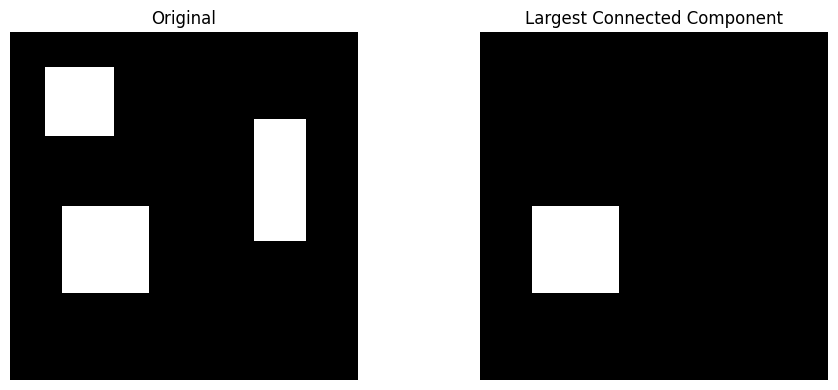

In [38]:
# Student task cell: measure areas and extract largest component
labeled_student, n_student = ndimage.label(cc_img)
areas = ndimage.sum(cc_img, labeled_student, index=range(1, n_student + 1))

print("Areas of components:", areas)

largest_label = np.argmax(areas) + 1
largest_component = (labeled_student == largest_label).astype(np.uint8)

show_pair(cc_img, largest_component, "Original", "Largest Connected Component")
plt.show()

# Comparison Summary

| Operation | Main Idea | Key Equation |
|---|---|---|
| Hit-or-Miss | Detect exact local pattern | $$(A \ominus B_1) \cap (A^c \ominus B_2)$$ |
| Boundary Extraction | Remove inner pixels, keep border | $$A - (A \ominus B)$$ |
| Hole Filling | Fill enclosed background regions | $$X_k = (X_{k-1} \oplus B) \cap A^c$$ |
| Connected Components | Grow one object from a seed | $$X_k = (X_{k-1} \oplus B) \cap A$$ |

---

## Common exam-style questions

1. Why is hit-or-miss considered a strict pattern detector?
2. Why does boundary extraction use erosion and subtraction?
3. What is the difference between a hole and ordinary background?
4. Why does connected component extraction require a seed in the classical iterative formulation?
5. How does 4-connectivity differ from 8-connectivity?

# Mini project for students

Create your own binary image containing:
- at least three objects,
- one hole,
- one thin line,
- one isolated point.

Then complete the following tasks:

1. Detect the isolated point using hit-or-miss.
2. Extract the boundaries of all objects.
3. Fill the hole.
4. Label all connected components.
5. Report the area of each connected component.

This project combines all four techniques into one workflow.

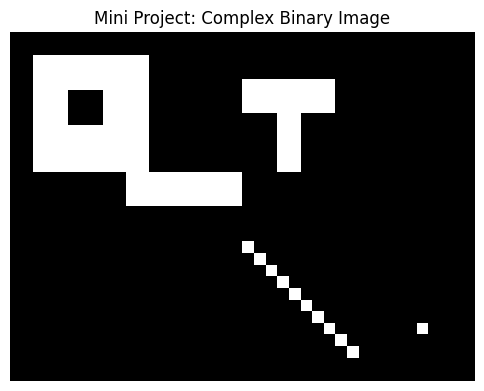


=== TASK 1: Detect Isolated Point ===


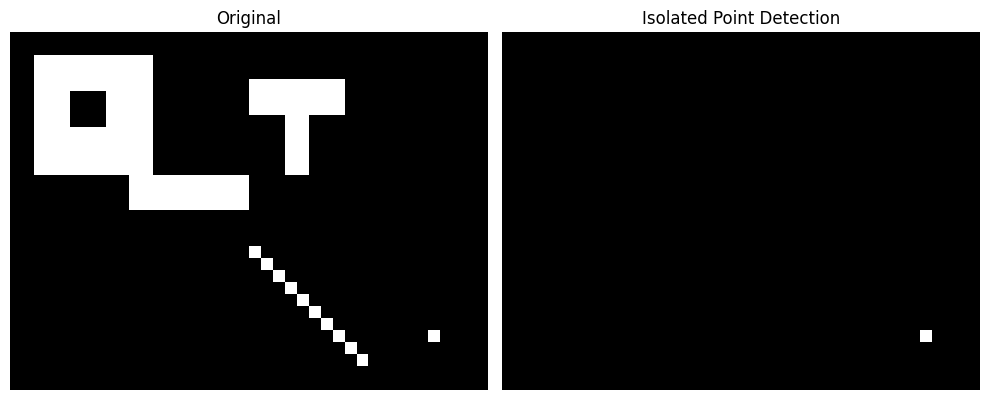

=== TASK 2: Extract Boundaries ===


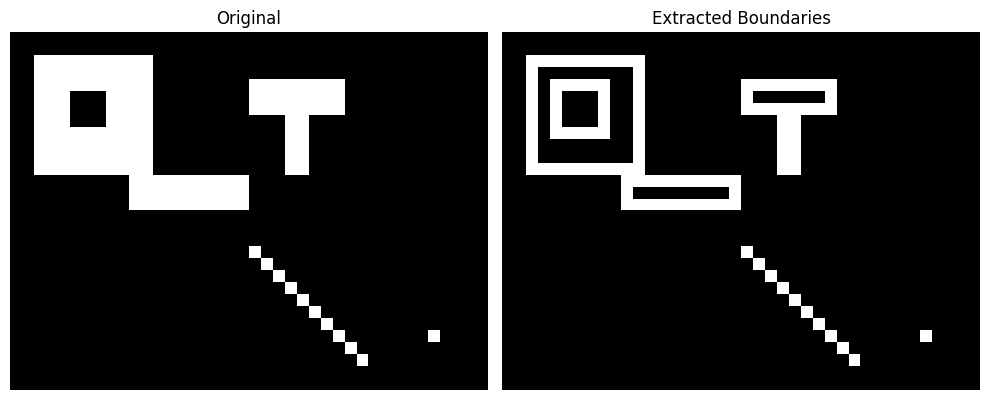

=== TASK 3: Fill the Hole ===


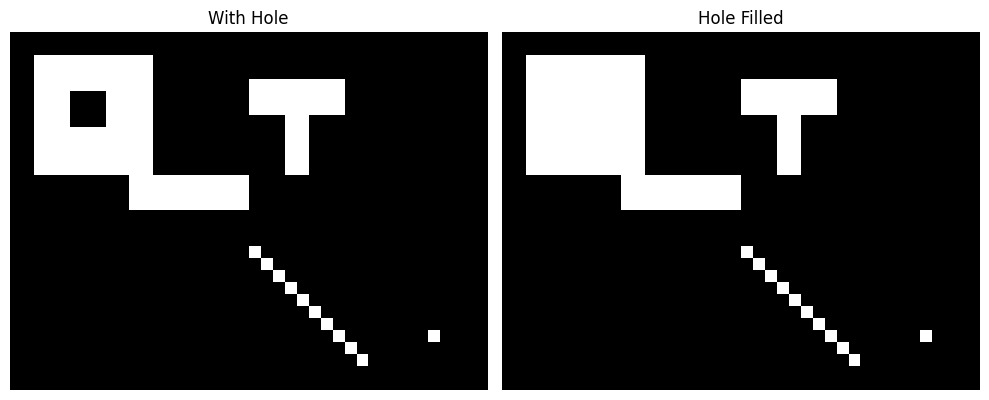

=== TASK 4: Label Connected Components ===
Number of connected components: 13


/tmp/ipykernel_3388/2031386262.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("nipy_spectral", num_comp + 1)


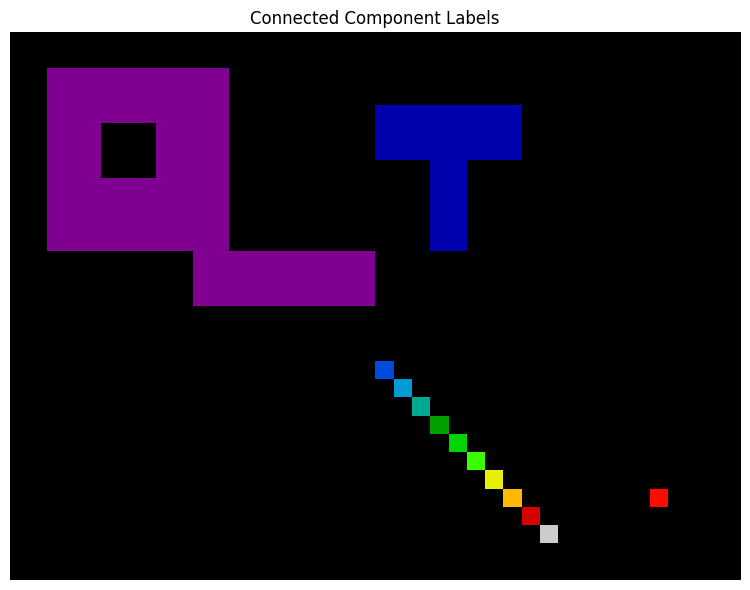

=== TASK 5: Component Areas ===
Component areas: [121.  34.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.]
  Component 1: 121 pixels
  Component 2: 34 pixels
  Component 3: 1 pixels
  Component 4: 1 pixels
  Component 5: 1 pixels
  Component 6: 1 pixels
  Component 7: 1 pixels
  Component 8: 1 pixels
  Component 9: 1 pixels
  Component 10: 1 pixels
  Component 11: 1 pixels
  Component 12: 1 pixels
  Component 13: 1 pixels


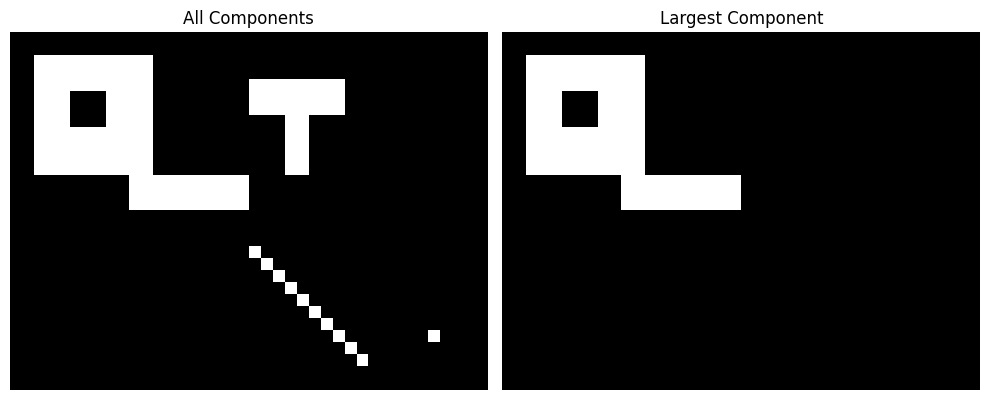


✅ Mini project complete!


In [39]:
# ===== MINI PROJECT: COMPLETE MORPHOLOGICAL OPERATIONS WORKFLOW =====

# Step 1: Create a complex binary image with all required features
project_img = np.zeros((30, 40), dtype=np.uint8)

# Object 1: Large square with a hole
project_img[2:12, 2:12] = 1
project_img[5:8, 5:8] = 0

# Object 2: T-shaped object
project_img[4:7, 20:28] = 1
project_img[7:12, 23:25] = 1

# Object 3: Diagonal line object
for i in range(10):
    project_img[18 + i, 20 + i] = 1

# Thin line connecting objects
project_img[12:15, 10:20] = 1

# Isolated single point
project_img[25, 35] = 1

show(project_img, "Mini Project: Complex Binary Image")
plt.show()

# ===== TASK 1: Detect isolated point using hit-or-miss =====
print("\n=== TASK 1: Detect Isolated Point ===")
B1_iso = np.array([[0,0,0],
                   [0,1,0],
                   [0,0,0]], dtype=bool)
B2_iso = np.array([[1,1,1],
                   [1,0,1],
                   [1,1,1]], dtype=bool)

fg_iso = ndimage.binary_erosion(project_img, structure=B1_iso)
bg_iso = ndimage.binary_erosion(1 - project_img, structure=B2_iso)
isolated_point = fg_iso & bg_iso

show_pair(project_img, isolated_point.astype(np.uint8), "Original", "Isolated Point Detection")
plt.show()

# ===== TASK 2: Extract boundaries of all objects =====
print("=== TASK 2: Extract Boundaries ===")
se = np.ones((3, 3), dtype=bool)
eroded_all = ndimage.binary_erosion(project_img, structure=se)
boundaries_all = project_img & (~eroded_all)

show_pair(project_img, boundaries_all.astype(np.uint8), "Original", "Extracted Boundaries")
plt.show()

# ===== TASK 3: Fill the hole =====
print("=== TASK 3: Fill the Hole ===")
inv = 1 - project_img
seed_border = np.zeros_like(inv, dtype=bool)
seed_border[0, :] = inv[0, :]
seed_border[-1, :] = inv[-1, :]
seed_border[:, 0] = inv[:, 0]
seed_border[:, -1] = inv[:, -1]

structure = np.array([[0,1,0],
                      [1,1,1],
                      [0,1,0]], dtype=bool)

outside = seed_border.copy()
while True:
    grown = ndimage.binary_dilation(outside, structure=structure) & inv.astype(bool)
    if np.array_equal(grown, outside):
        break
    outside = grown

holes_to_fill = inv.astype(bool) & (~outside)
filled_project = project_img.astype(bool) | holes_to_fill

show_pair(project_img, filled_project.astype(np.uint8), "With Hole", "Hole Filled")
plt.show()

# ===== TASK 4: Label all connected components =====
print("=== TASK 4: Label Connected Components ===")
labeled_proj, num_comp = ndimage.label(project_img)
print(f"Number of connected components: {num_comp}")

fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.cm.get_cmap("nipy_spectral", num_comp + 1)
ax.imshow(labeled_proj, cmap=cmap)
ax.set_title("Connected Component Labels")
ax.axis("off")
plt.tight_layout()
plt.show()

# ===== TASK 5: Report area of each connected component =====
print("=== TASK 5: Component Areas ===")
areas_proj = ndimage.sum(project_img, labeled_proj, index=range(1, num_comp + 1))
print(f"Component areas: {areas_proj}")

for i, area in enumerate(areas_proj, 1):
    print(f"  Component {i}: {int(area)} pixels")

largest_label_proj = np.argmax(areas_proj) + 1
largest_comp_proj = (labeled_proj == largest_label_proj).astype(np.uint8)

show_pair(project_img, largest_comp_proj, "All Components", "Largest Component")
plt.show()

print("\n✅ Mini project complete!")

# Apply all methods with reading an image

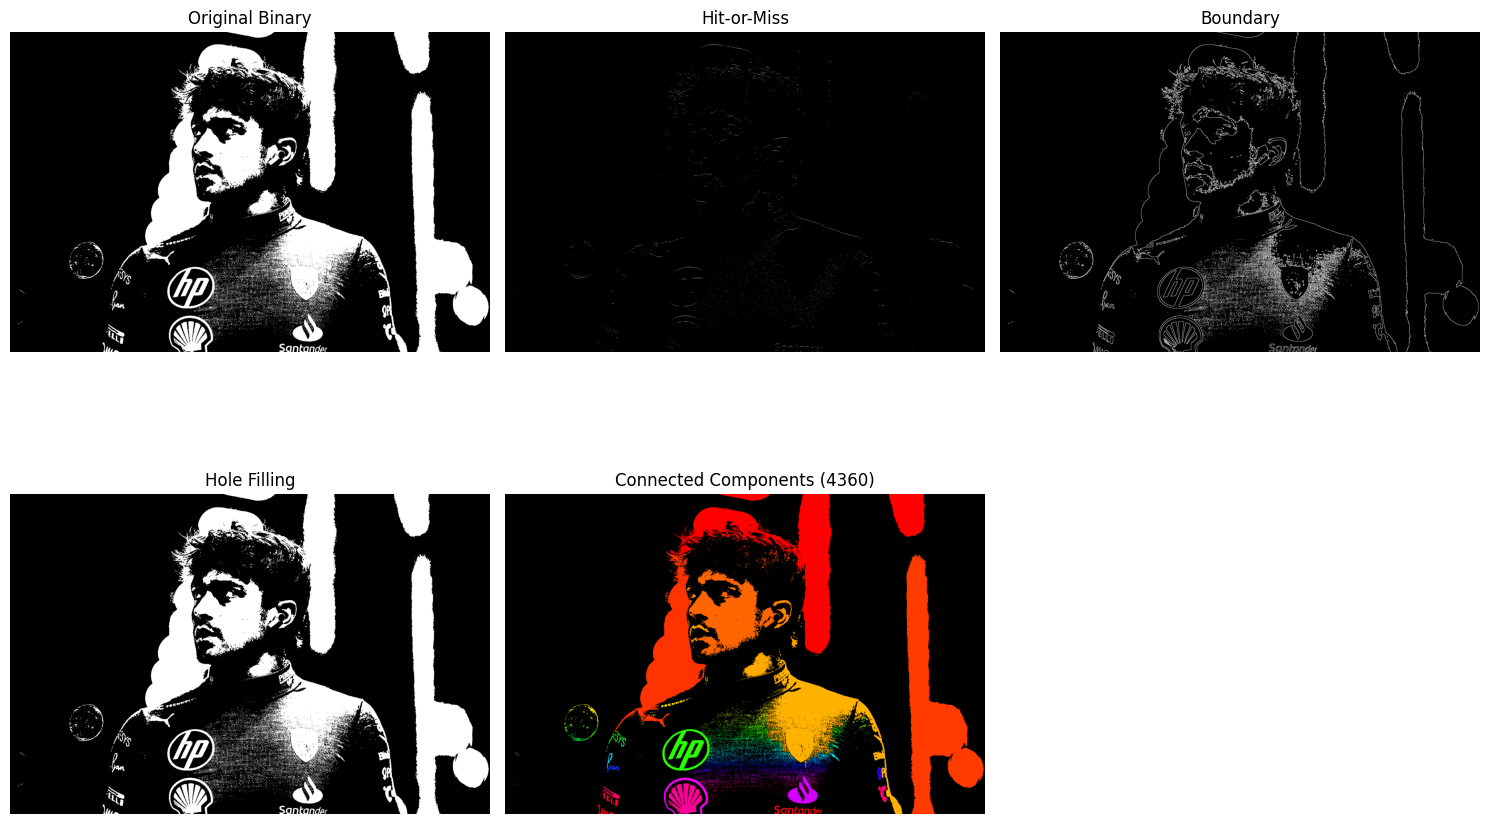

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read the specified image and convert to grayscale
img = cv2.imread("/content/sample_data/charles_leclerc.jpg", cv2.IMREAD_GRAYSCALE)

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load image. Please check the file path.")
else:
    # Binarize the image using a simple threshold
    # You might need to adjust the threshold value (e.g., 127) depending on the image content
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU) # Using OTSU for automatic thresholding

    # Hit-or-Miss
    binary01 = (binary // 255).astype(np.uint8)
    kernel = np.array([[-1,-1,-1],
                       [ 0, 1, 0],
                       [ 1, 1, 1]], dtype=np.int8)
    hitmiss = cv2.morphologyEx(binary01, cv2.MORPH_HITMISS, kernel) * 255

    # Boundary Extraction
    se = np.ones((3,3), np.uint8)
    boundary = cv2.subtract(binary, cv2.erode(binary, se))

    # Hole Filling
    # For hole filling, cv2.floodFill needs a border around the image
    # So we pad the image and define the seed point for floodFill as (0,0)
    # Note: floodFill fills background pixels connected to the seed.
    # To fill internal holes, we often fill the *external* background and subtract it from the inverted image.

    # Invert the binary image to find holes (black regions in white objects)
    inv_binary = cv2.bitwise_not(binary)

    # Create a mask for floodFill, 2 pixels wider/taller than the image
    h, w = inv_binary.shape[:2]
    mask = np.zeros((h + 2, w + 2), np.uint8)

    # Floodfill from the top-left corner (0,0) to find all external background pixels
    floodfilled_inv = inv_binary.copy()
    cv2.floodFill(floodfilled_inv, mask, (0, 0), 255)

    # The holes are the regions in the inverted image that were *not* floodfilled
    holes = cv2.bitwise_not(floodfilled_inv)

    # Combine original binary image with the detected holes to fill them
    filled = cv2.bitwise_or(binary, holes)

    # Connected Components
    # Note: cv2.connectedComponents returns labels from 0 (background) up to num_labels-1
    # We'll display all components for clarity, not just '1'
    num_labels, labels = cv2.connectedComponents(binary)

    # Create a colored map for visualization
    label_hue = np.uint8(179*labels/np.max(labels)) # Create a hue map
    blank_ch = 255*np.ones_like(label_hue) # Create a blank channel for value/saturation
    labeled_img_color = cv2.merge([label_hue, blank_ch, blank_ch])
    labeled_img_color = cv2.cvtColor(labeled_img_color, cv2.COLOR_HSV2BGR) # Convert to BGR
    labeled_img_color[labels==0] = 0 # Set background to black

    # Display
    plt.figure(figsize=(15,10))
    plt.subplot(231), plt.imshow(binary, cmap='gray'), plt.title("Original Binary"), plt.axis("off")
    plt.subplot(232), plt.imshow(hitmiss, cmap='gray'), plt.title("Hit-or-Miss"), plt.axis("off")
    plt.subplot(233), plt.imshow(boundary, cmap='gray'), plt.title("Boundary"), plt.axis("off")
    plt.subplot(234), plt.imshow(filled, cmap='gray'), plt.title("Hole Filling"), plt.axis("off")
    plt.subplot(235), plt.imshow(cv2.cvtColor(labeled_img_color, cv2.COLOR_BGR2RGB)), plt.title(f"Connected Components ({num_labels-1})"), plt.axis("off") # Display as RGB
    plt.tight_layout()
    plt.show()